# Outliers and Duplicates

Outliers distort statistical summaries, inflate error metrics, and mislead distance-based algorithms. Duplicates silently bias models toward over-represented patterns and inflate evaluation metrics. Both need careful detection before any modelling begins.

### What you will learn

| Section | Topic |
|---------|-------|
| 1 | Visualising outliers — boxplots and scatter plots |
| 2 | Detection: IQR method |
| 3 | Detection: Z-score method |
| 4 | Detection: Isolation Forest (multivariate) |
| 5 | Treatment: capping / winsorizing |
| 6 | Treatment: when to remove vs. transform |
| 7 | Detecting and handling duplicate rows |

> **Complement:** `dcai-lab/outliers/` covers Isolation Forest in the context of data-centric AI — this notebook focuses on the detection-to-treatment workflow.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

In [3]:
# --- Generate a synthetic dataset with controlled outliers and duplicates ---
rng = np.random.default_rng(42)
n = 300

df = pd.DataFrame({
    'age'    : np.clip(rng.normal(35, 10, n), 18, 80).round(1),
    'income' : np.exp(rng.normal(10.5, 0.5, n)).round(2),   # log-normal (right-skewed)
    'score'  : rng.normal(70, 12, n).round(1),
    'region' : rng.choice(['North', 'South', 'East', 'West'], n),
})

# Inject univariate outliers into 'age'
df.loc[rng.choice(n, 8, replace=False), 'age'] = rng.choice([2, 3, 150, 180], 8)

# Inject multivariate outliers: implausibly high income for young age
outlier_idx = rng.choice(n, 5, replace=False)
df.loc[outlier_idx, 'age']    = rng.integers(19, 23, 5)
df.loc[outlier_idx, 'income'] = rng.uniform(500_000, 900_000, 5)

# Inject exact duplicate rows
duplicates = df.sample(12, random_state=42)
df = pd.concat([df, duplicates], ignore_index=True)

print(f'Dataset shape: {df.shape}')
df.describe().round(2)

Dataset shape: (312, 4)


,age,income,score
count,312.00,312.00,312.00
mean,36.92,52363.47,69.17
std,21.70,90449.36,12.08
min,2.00,8248.08,37.90
25%,27.28,25586.44,60.90
50%,34.00,38021.68,69.85
75%,40.08,52833.27,76.78
max,180.00,835669.55,108.10


---
## Section 1 — Visualising Outliers

Always plot before computing. Box plots show univariate extremes; scatter plots reveal multivariate outliers that no single-column method would catch.

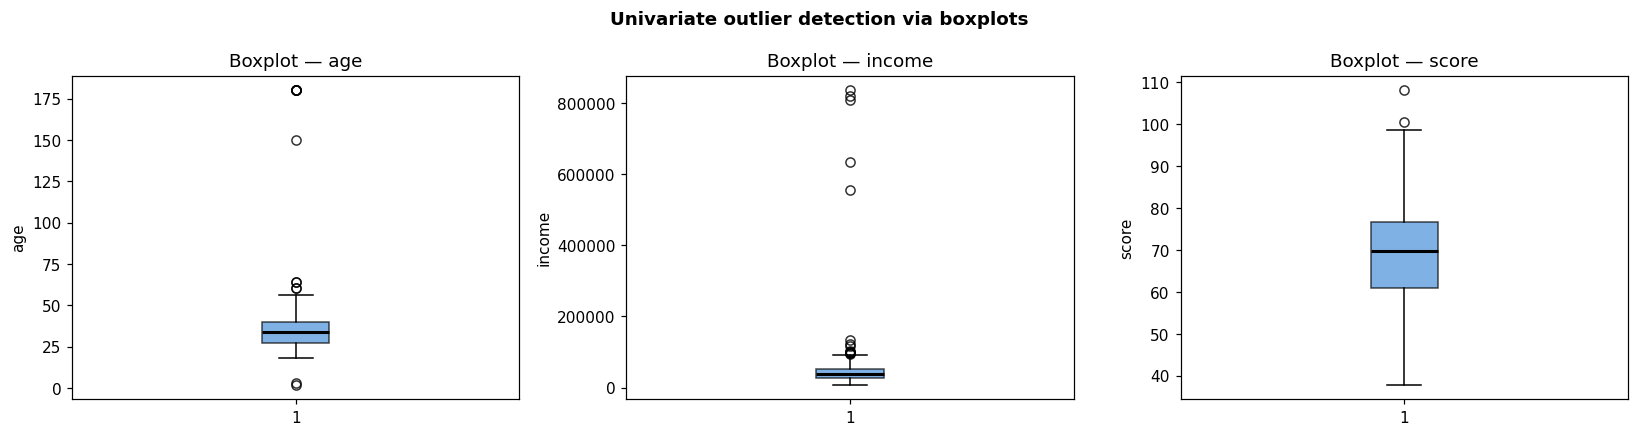

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Box plots for each numeric column
for ax, col in zip(axes, ['age', 'income', 'score']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4a90d9', alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', color='#e07b54', markersize=6, alpha=0.8))
    ax.set_title(f'Boxplot — {col}')
    ax.set_ylabel(col)

plt.suptitle('Univariate outlier detection via boxplots', fontweight='bold')
plt.tight_layout()
plt.show()

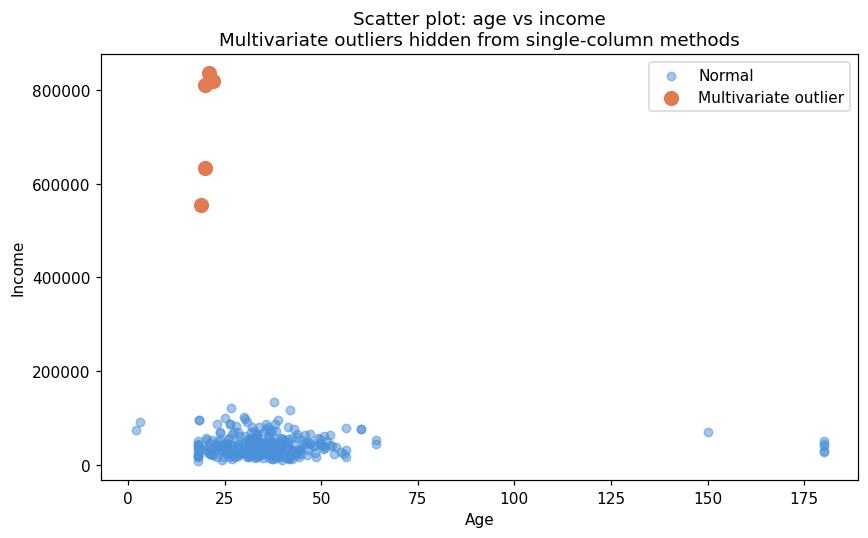

In [5]:
# Scatter plot: reveals multivariate outliers invisible in single-column views
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['age'], df['income'], alpha=0.5, s=30, color='#4a90d9', label='Normal')

# Highlight the injected multivariate outliers (high income + young age)
mv_mask = (df['income'] > 200_000) & (df['age'] < 25)
ax.scatter(df.loc[mv_mask, 'age'], df.loc[mv_mask, 'income'],
           color='#e07b54', s=80, zorder=5, label='Multivariate outlier')

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Scatter plot: age vs income\nMultivariate outliers hidden from single-column methods')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 2 — IQR Method

The **interquartile range (IQR)** method flags values that fall outside a fence:

```
Lower fence = Q1 - 1.5 × IQR
Upper fence = Q3 + 1.5 × IQR
```

The multiplier `1.5` is the standard (Tukey); use `3.0` for extreme outliers only.

**Strengths:** Simple, interpretable, no assumptions about distribution.  
**Weakness:** Univariate — misses multivariate outliers; ineffective on very skewed data.

In [6]:
def iqr_outlier_mask(series: pd.Series, multiplier: float = 1.5) -> pd.Series:
    """Return a boolean mask — True where the value is an IQR outlier."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - multiplier * iqr) | (series > q3 + multiplier * iqr)

for col in ['age', 'income', 'score']:
    mask = iqr_outlier_mask(df[col])
    print(f'{col:10s}  outliers={mask.sum():3d}  ({mask.mean()*100:.1f}%)')
    if mask.any():
        print(f'           values: {sorted(df.loc[mask, col].unique())[:8]}')

age         outliers= 12  (3.8%)
           values: [2.0, 3.0, 60.2, 64.1, 150.0, 180.0]
income      outliers= 14  (4.5%)
           values: [95665.75, 96327.23, 98582.42, 100462.18, 102589.44, 116288.16, 121808.75, 133097.45]
score       outliers=  2  (0.6%)
           values: [100.6, 108.1]


---
## Section 3 — Z-score Method

Flag values whose **standardised distance from the mean** exceeds a threshold (typically ±3):

```
z = (x − μ) / σ
```

**Strengths:** Works well for approximately normal distributions.  
**Weakness:** Sensitive to the outliers themselves — they inflate `σ`, masking themselves. Use `median` and `MAD` (modified Z-score) as a robust alternative.

In [7]:
def zscore_outlier_mask(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    z = np.abs(stats.zscore(series.dropna()))
    mask = pd.Series(False, index=series.index)
    mask.loc[series.dropna().index] = z > threshold
    return mask

def modified_zscore_mask(series: pd.Series, threshold: float = 3.5) -> pd.Series:
    """Robust z-score using median and MAD — less affected by the outliers themselves."""
    median = series.median()
    mad = np.abs(series - median).median()
    m_z = 0.6745 * np.abs(series - median) / (mad + 1e-9)
    return m_z > threshold

print('--- Standard Z-score (threshold=3) ---')
for col in ['age', 'income', 'score']:
    mask = zscore_outlier_mask(df[col])
    print(f'{col:10s}  outliers={mask.sum():3d}')

print('\n--- Modified Z-score / MAD (threshold=3.5) ---')
for col in ['age', 'income', 'score']:
    mask = modified_zscore_mask(df[col])
    print(f'{col:10s}  outliers={mask.sum():3d}')

--- Standard Z-score (threshold=3) ---
age         outliers=  6
income      outliers=  5
score       outliers=  1

--- Modified Z-score / MAD (threshold=3.5) ---
age         outliers=  6
income      outliers=  8
score       outliers=  0


---
## Section 4 — Isolation Forest (Multivariate)

Isolation Forest detects outliers by how quickly a point can be **isolated** in random feature splits — anomalous points are isolated in fewer splits. It handles multivariate outliers that univariate methods miss entirely.

**Strengths:** Catches complex, multivariate anomalies; scalable; no distributional assumption.  
**Weakness:** `contamination` parameter must be set; results are probabilistic, not a crisp threshold.

In [8]:
numeric_cols = ['age', 'income', 'score']
X = df[numeric_cols].copy()

# Scale first — Isolation Forest is not distance-based but scaling helps interpretability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# contamination: expected fraction of outliers in the dataset
iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
df['iso_label']  = iso.fit_predict(X_scaled)    # -1 = outlier, 1 = inlier
df['iso_score']  = iso.score_samples(X_scaled)  # lower = more anomalous

n_outliers = (df['iso_label'] == -1).sum()
print(f'Isolation Forest flagged {n_outliers} outliers ({n_outliers/len(df)*100:.1f}%)')
print('\nFlagged rows (sample):')
print(df[df['iso_label'] == -1][numeric_cols + ['iso_score']].sort_values('iso_score').head(10))

Isolation Forest flagged 16 outliers (5.1%)

Flagged rows (sample):
       age         income  score  iso_score
122   21.0  835669.546494   42.6  -0.750725
31   180.0   49949.460000  100.6  -0.735930
76    19.0  555331.628046   98.6  -0.731116
174   22.0  819004.334272   70.1  -0.720184
137   20.0  809734.360473   79.7  -0.717631
143  150.0   70286.200000   47.7  -0.689358
136  180.0   27807.190000   79.3  -0.678562
108   20.0  634451.987412   67.3  -0.674388
68   180.0   40181.140000   63.7  -0.670711
187  180.0   45032.990000   67.6  -0.658873


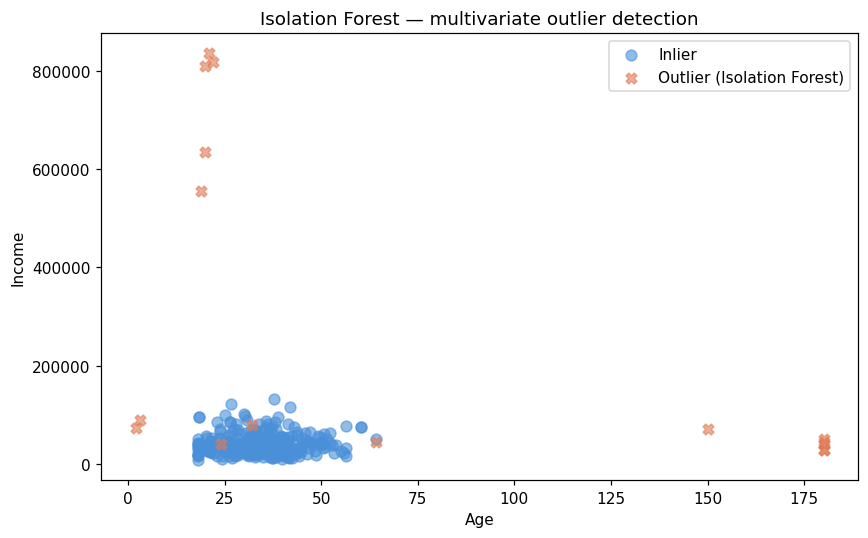

In [9]:
# Visualise: scatter plot coloured by Isolation Forest label
fig, ax = plt.subplots(figsize=(8, 5))

for label, color, marker, name in [
    (1,  '#4a90d9', 'o', 'Inlier'),
    (-1, '#e07b54', 'X', 'Outlier (Isolation Forest)'),
]:
    mask = df['iso_label'] == label
    ax.scatter(df.loc[mask, 'age'], df.loc[mask, 'income'],
               alpha=0.6, s=50, color=color, marker=marker, label=name)

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Isolation Forest — multivariate outlier detection')
ax.legend()
plt.tight_layout()
plt.show()

# Clean up diagnostic columns
df = df.drop(columns=['iso_label', 'iso_score'])

---
## Section 5 — Treatment: Capping / Winsorizing

Removing outliers loses data. **Winsorizing** caps extreme values at a chosen percentile — preserving the row while reducing the influence of the extreme value.

This is the preferred strategy when:
- The outlier is a measurement error, not a true observation
- You cannot afford to lose rows
- The variable is right-skewed (e.g. income, house prices)

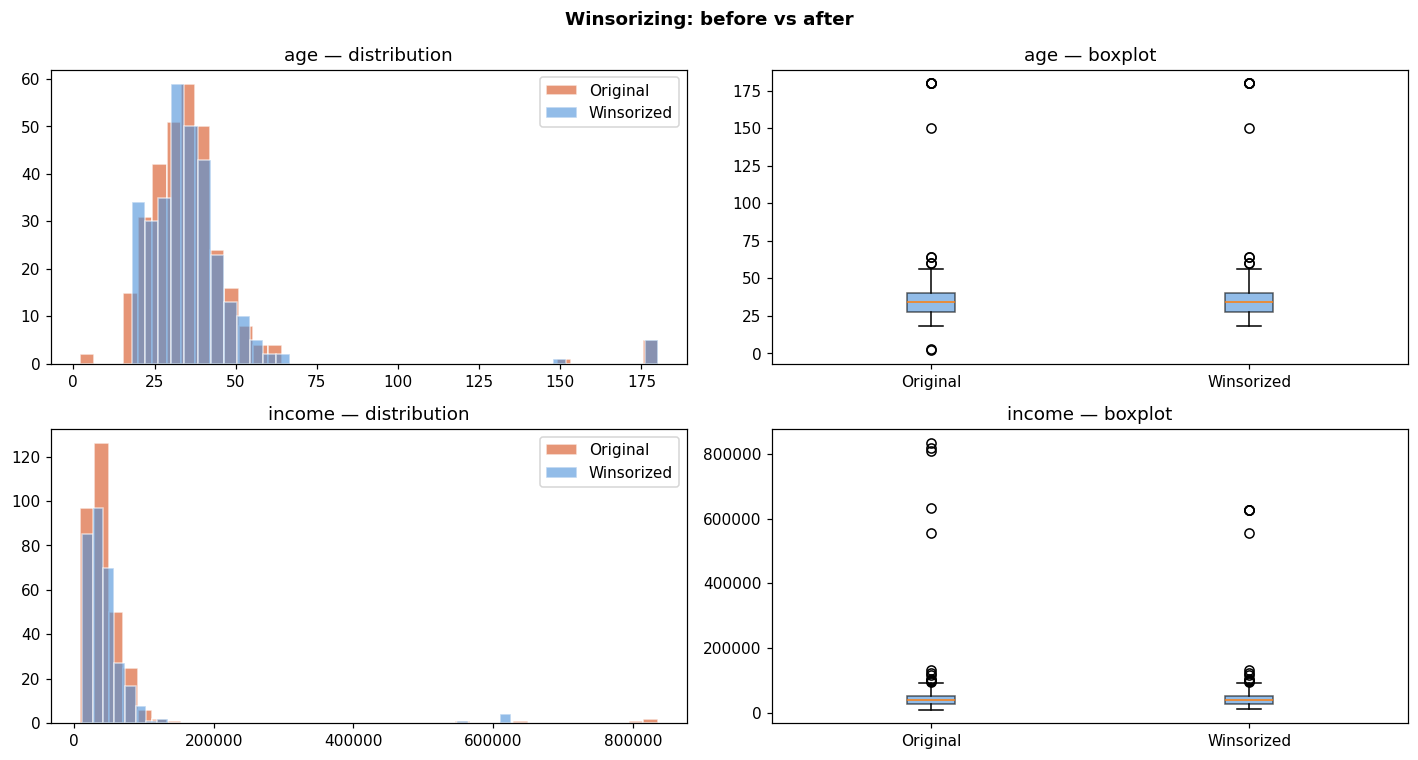

In [10]:
def winsorize(series: pd.Series, lower_pct: float = 0.01, upper_pct: float = 0.99) -> pd.Series:
    """Cap values at the specified percentile bounds."""
    lo = series.quantile(lower_pct)
    hi = series.quantile(upper_pct)
    return series.clip(lower=lo, upper=hi)

df['age_winsorized']    = winsorize(df['age'],    lower_pct=0.01, upper_pct=0.99)
df['income_winsorized'] = winsorize(df['income'], lower_pct=0.01, upper_pct=0.99)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for row, col in enumerate(['age', 'income']):
    original  = df[col]
    capped    = df[f'{col}_winsorized']

    # Distribution before / after
    axes[row][0].hist(original, bins=40, color='#e07b54', edgecolor='white', alpha=0.8, label='Original')
    axes[row][0].hist(capped,   bins=40, color='#4a90d9', edgecolor='white', alpha=0.6, label='Winsorized')
    axes[row][0].set_title(f'{col} — distribution')
    axes[row][0].legend()

    # Box plot comparison
    axes[row][1].boxplot([original, capped], labels=['Original', 'Winsorized'],
                         patch_artist=True,
                         boxprops=dict(facecolor='#4a90d9', alpha=0.6))
    axes[row][1].set_title(f'{col} — boxplot')

plt.suptitle('Winsorizing: before vs after', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6 — Treatment: When to Remove vs. Transform

| Situation | Recommended action |
|-----------|-------------------|
| Outlier is a **data entry error** (age=180) | Remove the row |
| Outlier is a **genuine extreme** value (billionaire income) | Winsorize or log-transform |
| Outlier is **rare but valid** (edge case the model should learn) | Keep it; document it |
| Algorithm is **distance-based** (KNN, SVM, PCA) | Scale first; consider removal or capping |
| Algorithm is **tree-based** (RF, XGBoost) | Trees split by rank — outliers have less impact; often safe to keep |

In [11]:
# Remove rows with physically impossible values (data entry errors)
error_mask = (df['age'] < 5) | (df['age'] > 120)
print(f'Rows with impossible age values: {error_mask.sum()}')
print(df.loc[error_mask, ['age', 'income', 'score']])

df_clean = df[~error_mask].copy()
print(f'\nShape after removing errors: {df.shape} → {df_clean.shape}')

Rows with impossible age values: 8
       age    income  score
31   180.0  49949.46  100.6
68   180.0  40181.14   63.7
136  180.0  27807.19   79.3
143  150.0  70286.20   47.7
187  180.0  45032.99   67.6
224    2.0  73270.31   47.7
225  180.0  29106.95   70.3
292    3.0  90278.03   65.1

Shape after removing errors: (312, 6) → (304, 6)


---
## Section 7 — Detecting and Handling Duplicates

Duplicates cause:
- **Training data leakage** — if the same row ends up in both train and validation sets, evaluation metrics are inflated
- **Model bias** — over-represented rows skew learned decision boundaries

Duplicate types:
- **Exact duplicates** — every column identical
- **Near-duplicates** — same entity, slightly different values (e.g. data entry variations)
- **Key duplicates** — same ID with different values (update conflict)

In [12]:
# --- Detect exact duplicates ---
n_dup = df.duplicated().sum()
print(f'Exact duplicate rows: {n_dup}  ({n_dup/len(df)*100:.1f}%)')

# View a sample of duplicated rows alongside their original
duplicated_rows = df[df.duplicated(keep=False)].sort_values(['age', 'income'])
print(f'\nAll rows involved in duplication ({len(duplicated_rows)} total):')
print(duplicated_rows.head(10))

Exact duplicate rows: 12  (3.8%)

All rows involved in duplication (24 total):
      age    income  score region  age_winsorized  income_winsorized
109  18.0  18991.82   77.8  South            18.0           18991.82
307  18.0  18991.82   77.8  South            18.0           18991.82
152  18.3  96327.23   57.8  South            18.3           96327.23
302  18.3  96327.23   57.8  South            18.3           96327.23
5    22.0  21451.52   76.5   West            22.0           21451.52
308  22.0  21451.52   76.5   West            22.0           21451.52
9    26.5  86349.28   76.5   West            26.5           86349.28
303  26.5  86349.28   76.5   West            26.5           86349.28
237  33.4  64466.84   87.1   East            33.4           64466.84
310  33.4  64466.84   87.1   East            33.4           64466.84


In [13]:
# --- Remove duplicates ---
# keep='first' retains the first occurrence and drops subsequent identical rows
df_deduped = df_clean.drop_duplicates(keep='first')
print(f'Shape before dedup: {df_clean.shape}')
print(f'Shape after dedup : {df_deduped.shape}')
print(f'Rows removed       : {len(df_clean) - len(df_deduped)}')

Shape before dedup: (304, 6)
Shape after dedup : (292, 6)
Rows removed       : 12


In [14]:
# --- Subset duplicates: duplicated on a key column only ---
# Useful when you have an ID column and want to detect conflicting records
df_ids = df_deduped.copy()
df_ids['user_id'] = range(len(df_ids))

# Inject two rows with the same user_id but different values
df_ids.loc[0, 'user_id'] = df_ids.loc[5, 'user_id']  # same ID, different data

key_dups = df_ids.duplicated(subset=['user_id'], keep=False)
print(f'Rows with duplicate user_id: {key_dups.sum()}')
print(df_ids[key_dups][['user_id', 'age', 'income', 'score']])

Rows with duplicate user_id: 2
   user_id   age    income  score
0        5  38.0  86135.34   76.2
5        5  22.0  21451.52   76.5


---
## Key Takeaways

1. **Always visualise first** — box plots catch univariate outliers; scatter plots catch multivariate ones.
2. **IQR** is simple and interpretable for symmetric distributions; **modified Z-score** (MAD) is more robust for skewed data.
3. **Isolation Forest** is the go-to for multivariate anomaly detection — it catches outliers no single-column method would find.
4. **Don't default to removal** — winsorizing or log-transforming preserves data while reducing outlier influence.
5. **Tree-based models are outlier-tolerant**; distance-based models (KNN, SVM, PCA) are not — your treatment strategy depends on the algorithm.
6. **Always check for duplicates before splitting** — a duplicate spanning train/test is silent data leakage.

---
## Exercises

1. Load the `seaborn` `diamonds` dataset. Use IQR to detect outliers in the `price` column. How many are flagged?
2. Apply Isolation Forest with `contamination=0.02`. Do the flagged rows overlap with the IQR flags?
3. Winsorize `price` at the 1st and 99th percentiles. Compare the R² of a linear regression model predicting price before and after winsorizing.
4. The `diamonds` dataset has no true duplicates. Artificially inject 50 and verify your deduplication code removes them correctly.

In [17]:
# ========== Setup ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ========== Load diamonds dataset from local file ==========
file_path = r'C:\Users\35111\Downloads\OneDrive_1_2026-5-26\diamonds.csv'
diamonds = pd.read_csv(file_path)
print("Diamonds dataset loaded from local file.")
print("Shape:", diamonds.shape)

# ========== Exercise 1: IQR outlier detection on 'price' ==========
print("\n" + "="*60)
print("Exercise 1: IQR outlier detection on 'price'")
print("="*60)

price = diamonds['price']
Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers_iqr = price[(price < lower_fence) | (price > upper_fence)]
print(f"Number of price outliers by IQR: {len(outliers_iqr)}")
print(f"Percentage: {len(outliers_iqr)/len(price)*100:.2f}%")
print(f"Lower fence: {lower_fence:.2f}, Upper fence: {upper_fence:.2f}")

# ========== Exercise 2: Isolation Forest & overlap with IQR ==========
print("\n" + "="*60)
print("Exercise 2: Isolation Forest (contamination=0.02) and overlap with IQR")
print("="*60)

numeric_cols = diamonds.select_dtypes(include=[np.number]).columns
X_num = diamonds[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

iso = IsolationForest(contamination=0.02, random_state=42)
diamonds['iso_outlier'] = iso.fit_predict(X_scaled)
outliers_iso = diamonds[diamonds['iso_outlier'] == -1]
print(f"Outliers flagged by Isolation Forest: {len(outliers_iso)}")
print(f"Percentage: {len(outliers_iso)/len(diamonds)*100:.2f}%")

outliers_iqr_mask = (price < lower_fence) | (price > upper_fence)
overlap = diamonds[outliers_iqr_mask & (diamonds['iso_outlier'] == -1)]
print(f"Overlap (both methods): {len(overlap)}")
if len(outliers_iqr) > 0:
    print(f"Overlap % of IQR outliers: {len(overlap)/len(outliers_iqr)*100:.2f}%")
if len(outliers_iso) > 0:
    print(f"Overlap % of Isolation Forest outliers: {len(overlap)/len(outliers_iso)*100:.2f}%")

# ========== Exercise 3: Winsorize price and compare regression R² ==========
print("\n" + "="*60)
print("Exercise 3: Winsorize price (1st & 99th percentiles) and compare R²")
print("="*60)

def winsorize(series, lower=0.01, upper=0.99):
    q_low = series.quantile(lower)
    q_high = series.quantile(upper)
    return series.clip(lower=q_low, upper=q_high)

diamonds['price_winsorized'] = winsorize(diamonds['price'])

features = ['carat', 'depth', 'table', 'x', 'y', 'z']
X = diamonds[features].copy()
y_orig = diamonds['price']
y_wins = diamonds['price_winsorized']

model = LinearRegression()
cv_orig = cross_val_score(model, X, y_orig, cv=5, scoring='r2')
cv_wins = cross_val_score(model, X, y_wins, cv=5, scoring='r2')

print(f"Original price R²: {cv_orig.mean():.4f} ± {cv_orig.std():.4f}")
print(f"Winsorized price R²: {cv_wins.mean():.4f} ± {cv_wins.std():.4f}")

# ========== Exercise 4: Inject duplicates and verify deduplication ==========
print("\n" + "="*60)
print("Exercise 4: Inject 50 duplicates and verify deduplication")
print("="*60)

# Use a copy and remove any existing duplicates first
df_test = diamonds.drop_duplicates().copy()
print(f"Original shape (after removing any pre-existing duplicates): {df_test.shape}")

# Inject exactly 50 duplicates
np.random.seed(42)
indices_to_dup = np.random.choice(df_test.index, size=50, replace=False)
duplicates = df_test.loc[indices_to_dup].copy()
df_with_dups = pd.concat([df_test, duplicates], ignore_index=True)
print(f"After injecting 50 duplicates: {df_with_dups.shape}")

# Check duplicate count before deduplication
dup_before = df_with_dups.duplicated().sum()
print(f"Duplicate rows count before deduplication: {dup_before}")

# Deduplicate
df_deduped = df_with_dups.drop_duplicates(keep='first')
print(f"After deduplication: {df_deduped.shape}")
rows_removed = len(df_with_dups) - len(df_deduped)
print(f"Rows removed: {rows_removed}")

# Verify
assert rows_removed == 50, f"Deduplication removed {rows_removed} rows, expected 50"
print("Verification passed: Exactly 50 duplicate rows were removed.")

Diamonds dataset loaded from local file.
Shape: (53940, 10)

Exercise 1: IQR outlier detection on 'price'
Number of price outliers by IQR: 3540
Percentage: 6.56%
Lower fence: -5611.38, Upper fence: 11885.62

Exercise 2: Isolation Forest (contamination=0.02) and overlap with IQR
Outliers flagged by Isolation Forest: 1079
Percentage: 2.00%
Overlap (both methods): 833
Overlap % of IQR outliers: 23.53%
Overlap % of Isolation Forest outliers: 77.20%

Exercise 3: Winsorize price (1st & 99th percentiles) and compare R²
Original price R²: -0.6686 ± 1.4026
Winsorized price R²: -0.6865 ± 1.4333

Exercise 4: Inject 50 duplicates and verify deduplication
Original shape (after removing any pre-existing duplicates): (53794, 12)
After injecting 50 duplicates: (53844, 12)
Duplicate rows count before deduplication: 50
After deduplication: (53794, 12)
Rows removed: 50
Verification passed: Exactly 50 duplicate rows were removed.
